### **Import das bibliotecas**

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

### **1- Import do DataSet**

In [8]:
import kagglehub
path = kagglehub.dataset_download("menegidio/fishmorph-dataset")
print(path)

Using Colab cache for faster access to the 'fishmorph-dataset' dataset.
/kaggle/input/fishmorph-dataset


In [9]:
import os
arquivo = os.path.join(path,"FISHMORPH_Family_Dataset.csv")
df = pd.read_csv(arquivo)
df.head()

,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Family
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,Cyprinidae
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,Cichlidae
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,Cyprinidae
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,Cyprinidae
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,Cyprinidae


### **2- Dimensões do Dataset**

In [10]:
print( "Quantidade de linhas:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])

Quantidade de linhas: 8342
Quantidade de colunas: 11


### **3- Informações dos Dados**

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8342 entries, 0 to 8341
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MBl     8342 non-null   float64
 1   BEl     8342 non-null   float64
 2   VEp     8342 non-null   float64
 3   REs     8342 non-null   float64
 4   OGp     8342 non-null   float64
 5   RMl     8342 non-null   float64
 6   BLs     8342 non-null   float64
 7   PFv     8342 non-null   float64
 8   PFs     8342 non-null   float64
 9   CPt     8342 non-null   float64
 10  Family  8342 non-null   object 
dtypes: float64(10), object(1)
memory usage: 717.0+ KB


### **4- Estatísticas Descritivas**

In [12]:
df.describe()

,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt
count,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000
mean,22.004517,4.452438,0.549087,0.391665,0.381768,0.399786,0.571818,0.285316,0.189343,2.560795
std,33.612007,2.338235,0.094883,0.132814,0.194352,0.302658,0.117486,0.155629,0.056109,1.016659
min,1.200000,1.033084,0.159248,0.000000,0.000000,0.000000,0.224525,0.000000,0.000000,0.000000
25%,7.000000,3.139102,0.487993,0.293205,0.278014,0.257999,0.490052,0.193134,0.157972,1.999744
50%,12.600000,4.038851,0.546213,0.389429,0.406904,0.361436,0.564739,0.275039,0.183497,2.436329
75%,24.500000,5.002621,0.605125,0.486221,0.516001,0.490671,0.648039,0.368876,0.215031,2.919818
max,800.000000,43.728161,1.000000,1.026667,1.026316,7.060344,1.230105,0.857097,0.511113,15.452061


### **5- Verificação de dados nulos**

Foi realizada a verificação de valores ausentes em todas as colunas do dataset. Não foram encontrados valores nulos.

In [22]:
print("Total de valores nulos: ", df.isnull().sum().sum())

Total de valores nulos:  0


### **6- Verificação de dados duplicados**

Foi identificado 1 registro duplicado no dataset. Esse registro foi removido para evitar repetição de informações durante o treinamento do modelo.

In [20]:
print("Total de valores duplicados: ", df.duplicated().sum())

Total de valores duplicados:  1


In [23]:
df = df.drop_duplicates()

print("Duplicados após tratamento:", df.duplicated().sum())

Duplicados após tratamento: 0


### **7- Distribuição das Categorais**
Nesta etapa é analisada a distribuição das classes presentes na variável alvo `Family`, permitindo verificar a quantidade de registros em cada família.

In [24]:
df["Family"].value_counts()

,count
Family,
Cyprinidae,1545
Cichlidae,1060
Characidae,732
Loricariidae,427
Percidae,190
...,...
Sillaginidae,1
Serrasalmidae,1
Bythitidae,1


In [25]:
df["Family"].value_counts()

,count
Family,
Cyprinidae,1545
Cichlidae,1060
Characidae,732
Loricariidae,427
Percidae,190
...,...
Sillaginidae,1
Serrasalmidae,1
Bythitidae,1


In [26]:
print( "Quantidade de famílias:", df["Family"].nunique())

Quantidade de famílias: 197


### **8- Visualização da distribuição das famílias**

O gráfico abaixo apresenta a quantidade de registros das famílias mais frequentes no dataset.

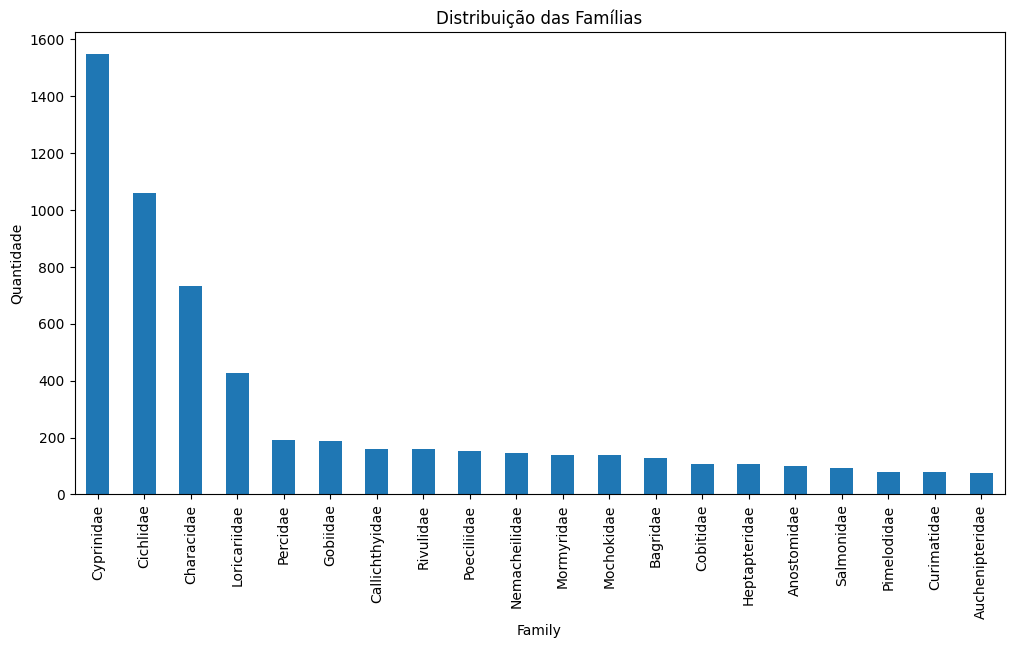

In [28]:
familias = (df["Family"].value_counts().head(20))
plt.figure(figsize=(12, 6))
familias.plot(kind="bar")
plt.title("Distribuição das Famílias")
plt.xlabel("Family")
plt.ylabel("Quantidade")
plt.xticks(rotation=90)

plt.show()

## **9- Separação das Variáveis**

As variáveis morfológicas são utilizadas como atributos de entrada `X`, enquanto `Family` é utilizada como variável alvo `y`.

In [36]:
X = df.drop("Family",axis=1)
y = df["Family"]

## **10 - Codificação da Variável Alvo**

Como a variável `Family` contém categorias em formato textual, será utilizado o `LabelEncoder` para transformar as classes em valores numéricos.

In [31]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [32]:
print("Quantidade de classes:", len(encoder.classes_))
print("Classes:")
print(encoder.classes_)

Quantidade de classes: 197
Classes:
['Abyssocottidae' 'Acestrorhynchidae' 'Achiridae' 'Acipenseridae'
 'Adrianichthyidae' 'Akysidae' 'Alestidae' 'Ambassidae' 'Amblycipitidae'
 'Amblyopsidae' 'Ambylopsidae' 'Amiidae' 'Amphiliidae' 'Anabantidae'
 'Anablepidae' 'Anchariidae' 'Anguillidae' 'Anostomidae' 'Aphredoderidae'
 'Aplocheilidae' 'Apogonidae' 'Apteronotidae' 'Arapaimidae' 'Ariidae'
 'Aspredinidae' 'Astroblepidae' 'Atherinidae' 'Atherinopsidae'
 'Auchenipteridae' 'Austroglanididae' 'Badidae' 'Bagridae' 'Balitoridae'
 'Batrachoididae' 'Bedotiidae' 'Belonidae' 'Blenniidae' 'Bythitidae'
 'Callichthyidae' 'Callionymidae' 'Carangidae' 'Catostomidae'
 'Centrarchidae' 'Centropomidae' 'Cetopsidae' 'Chacidae' 'Chanidae'
 'Channidae' 'Characidae' 'Chaudhuriidae' 'Cheimarrhichthyidae'
 'Chilodontidae' 'Cichlidae' 'Citharinidae' 'Clariidae' 'Claroteidae'
 'Clupeidae' 'Cobitidae' 'Comephoridae' 'Cottidae' 'Cottocomephoridae'
 'Crenuchidae' 'Ctenoluciidae' 'Curimatidae' 'Cynodontidae'
 'Cynoglossi

## **11 - Divisão entre Treino e Teste**

O dataset foi dividido em conjunto de treinamento e conjunto de teste. Foram utilizados 80% dos dados para treinamento e 20% para teste, com `random_state=42`.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [34]:
print("Treino:", X_train.shape)
print("Teste:",X_test.shape)

Treino: (6672, 10)
Teste: (1669, 10)


## **13 - Padronização dos Dados**

Como o SVM é sensível à escala das variáveis, os dados foram padronizados utilizando `StandardScaler`.

In [37]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

## **14 - GridSearchCV com Cross Validation**

Foi utilizado o `GridSearchCV` para realizar validação cruzada e testar diferentes combinações dos hiperparâmetros `kernel`, `C` e `gamma`.

Foram utilizados quatro valores diferentes para cada hiperparâmetro.

In [38]:
parametros = {
    "kernel": [
        "linear",
        "rbf",
        "poly",
        "sigmoid"
    ],

    "C": [
        0.1,
        1,
        10,
        100
    ],

    "gamma": [
        "scale",
        "auto",
        0.01,
        0.1
    ]
}

In [39]:
grid = GridSearchCV(
    SVC(),
    parametros,
    cv=5
)

grid.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.01, 0.1],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']})

## **16 - Predição no Conjunto de Teste**

O melhor modelo encontrado pelo GridSearchCV é utilizado para realizar as previsões no conjunto de teste.

In [40]:
modelo = grid.best_estimator_
y_pred = modelo.predict(X_test)

## **17 - Acurácia Final**

A acurácia final é calculada utilizando as previsões realizadas no conjunto de teste.

In [41]:
acuracia = accuracy_score(y_test, y_pred)
print("Acurácia no teste:",acuracia)

Acurácia no teste: 0.6387058118633913


In [42]:
print("Acurácia no teste:",round(acuracia * 100,2 ),"%")

Acurácia no teste: 63.87 %


## **18 - Matriz de Confusão**

A matriz de confusão permite visualizar os acertos e erros do modelo na classificação das famílias.

In [43]:
matriz = confusion_matrix(y_test,y_pred)
print(matriz)

[[1 0 0 ... 0 0 0]
 [0 3 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 7 0]
 [0 0 0 ... 0 0 0]]


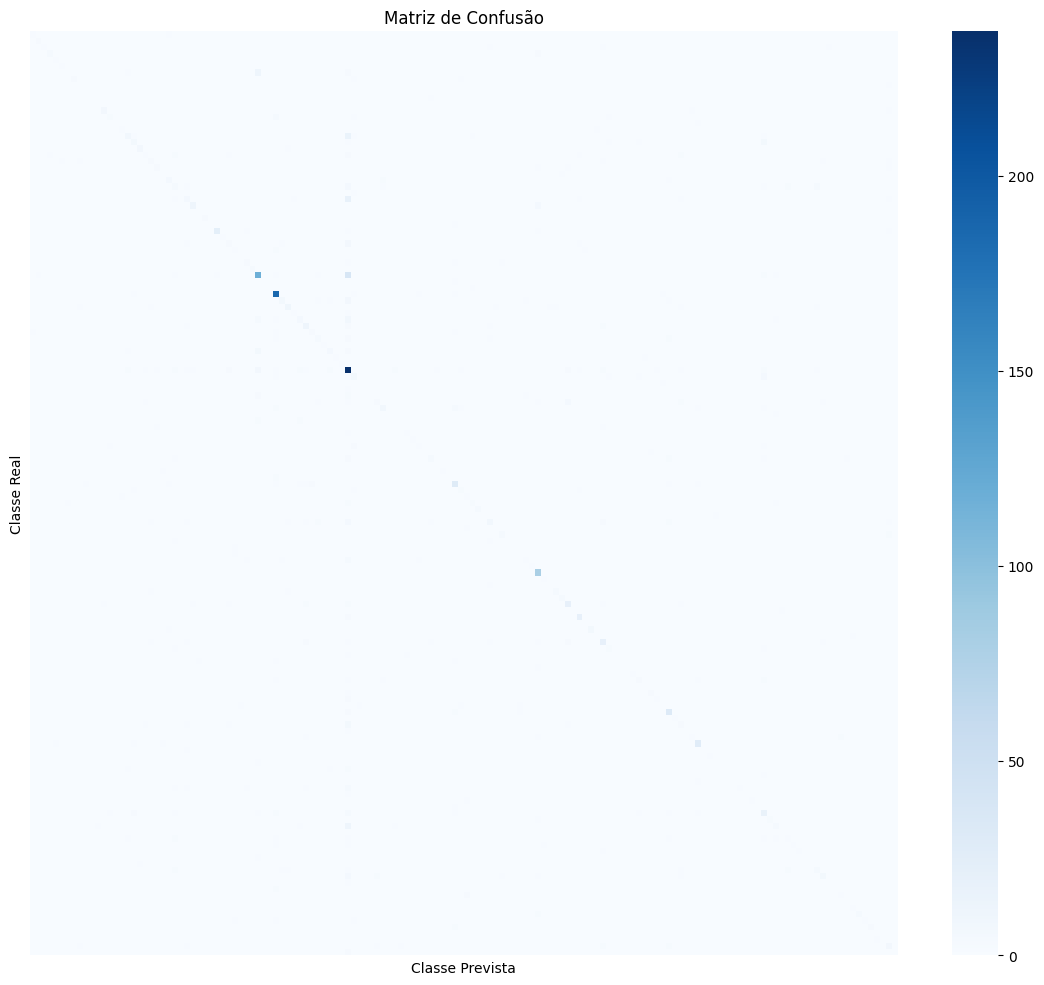

In [45]:
plt.figure(
    figsize=(14, 12)
)

sns.heatmap(
    matriz,
    cmap="Blues",
    xticklabels=False,
    yticklabels=False
)

plt.title(
    "Matriz de Confusão"
)

plt.xlabel(
    "Classe Prevista"
)

plt.ylabel(
    "Classe Real"
)

plt.show()

A matriz de confusão apresenta grande dimensão devido à quantidade de classes presentes na variável Family. As células mais intensas na diagonal principal representam classificações corretas, enquanto valores fora da diagonal indicam erros de classificação.